<a href="https://colab.research.google.com/github/Shaikh-Uzair-Ahmed/1BM23CS307/blob/ML/%E2%80%9C1BM23CS307_Lab_7_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

           IRIS DATASET - RANDOM FOREST CLASSIFIER
Dataset shape : (150, 5)
Columns       : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Class dist.   :
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50

Train samples : 105
Test  samples : 45

-------------------------------------------------------
STEP 1 : Default Random Forest  (n_estimators = 10)
-------------------------------------------------------
Prediction Score (n_estimators=10) : 0.9111  (91.11%)

-------------------------------------------------------
STEP 2 : Fine-Tuning — varying n_estimators (1 to 50)
-------------------------------------------------------
 Trees     Score
------------------
     1    0.8667  ← best
     2    0.8889  ← best
     3    0.8889
     4    0.8889
     5    0.9111  ← best
     6    0.8889
     7    0.9111
     8    0.9111
     9    0.9111
    10    0.9111
    11    0.9111
    12    0.9111
    13    0.9111
    14    0.9111
    15    0.9111
   

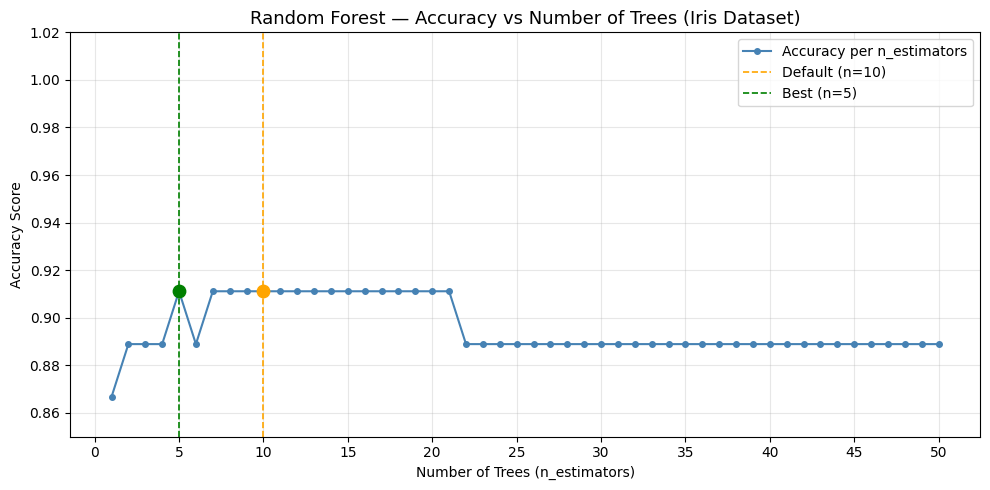


Plot saved → rf_accuracy_vs_trees.png


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ─────────────────────────────────────────────
# 1. Load Dataset
# ─────────────────────────────────────────────
try:
    df = pd.read_csv('iris (1).csv')
except FileNotFoundError:
    print("Error: 'iris.csv' not found. Please place the file in the working directory.")
    raise

print("=" * 55)
print("           IRIS DATASET - RANDOM FOREST CLASSIFIER")
print("=" * 55)
print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print(f"Class dist.   :\n{df.iloc[:, -1].value_counts().to_string()}\n")

# ─────────────────────────────────────────────
# 2. Prepare Features and Target
# ─────────────────────────────────────────────
X = df.iloc[:, :-1]   # All columns except the last
y = df.iloc[:, -1]    # Last column is the target label

# ─────────────────────────────────────────────
# 3. Train / Test Split  (70% train, 30% test)
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train samples : {len(X_train)}")
print(f"Test  samples : {len(X_test)}\n")

# ─────────────────────────────────────────────
# 4. Default RF — n_estimators = 10
# ─────────────────────────────────────────────
print("-" * 55)
print("STEP 1 : Default Random Forest  (n_estimators = 10)")
print("-" * 55)

rf_default = RandomForestClassifier(n_estimators=10, random_state=42)
rf_default.fit(X_train, y_train)

y_pred_default = rf_default.predict(X_test)
score_default  = accuracy_score(y_test, y_pred_default)

print(f"Prediction Score (n_estimators=10) : {score_default:.4f}  ({score_default*100:.2f}%)\n")

# ─────────────────────────────────────────────
# 5. Fine-Tune — vary n_estimators from 1 to 50
# ─────────────────────────────────────────────
print("-" * 55)
print("STEP 2 : Fine-Tuning — varying n_estimators (1 to 50)")
print("-" * 55)

n_estimators_range = range(1, 51)
scores             = []
best_score         = 0
best_n_estimators  = 1

print(f"{'Trees':>6}  {'Score':>8}")
print("-" * 18)

for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    score = accuracy_score(y_test, rf.predict(X_test))
    scores.append(score)

    marker = "  ← best" if score > best_score else ""
    if score > best_score:
        best_score        = score
        best_n_estimators = n

    print(f"{n:>6}  {score:>8.4f}{marker}")

# ─────────────────────────────────────────────
# 6. Summary
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("RESULTS SUMMARY")
print("=" * 55)
print(f"Default score  (n_estimators=10) : {score_default:.4f}  ({score_default*100:.2f}%)")
print(f"Best score     (n_estimators={best_n_estimators:>2}) : {best_score:.4f}  ({best_score*100:.2f}%)")
print(f"Improvement                      : {(best_score - score_default)*100:+.2f}%")
print("=" * 55)

# ─────────────────────────────────────────────
# 7. Plot — Accuracy vs Number of Trees
# ─────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(list(n_estimators_range), scores, marker='o', markersize=4,
         linewidth=1.5, color='steelblue', label='Accuracy per n_estimators')

# Highlight default (n=10)
plt.axvline(x=10, color='orange', linestyle='--', linewidth=1.2, label='Default (n=10)')
plt.scatter([10], [score_default], color='orange', zorder=5, s=80)

# Highlight best
plt.axvline(x=best_n_estimators, color='green', linestyle='--', linewidth=1.2,
            label=f'Best (n={best_n_estimators})')
plt.scatter([best_n_estimators], [best_score], color='green', zorder=5, s=80)

plt.title('Random Forest — Accuracy vs Number of Trees (Iris Dataset)', fontsize=13)
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy Score')
plt.xticks(range(0, 51, 5))
plt.ylim(0.85, 1.02)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rf_accuracy_vs_trees.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved → rf_accuracy_vs_trees.png")
